# Analysis Examples Demonstration

Provides good first overview of here implemented functions.

## 1. Setup & Synthetic Data

In [1]:
%matplotlib inline
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from neural_cca import (
    load_from_arrays,
    steps2degree,
)

print("Imports successful")

Imports successful


In [ ]:
# ---------------------------------------------------------------------------
# Generate spike trains via Poisson process (25 kHz, 0.04 ms bins)
# Two clusters are generated independently, then merged.
# ---------------------------------------------------------------------------
rng = np.random.default_rng(42)

# --- Stimulus protocol -------------------------------------------------------
n_orientations = 12
n_repeats = 20
n_trials = n_orientations * n_repeats

angles_map = steps2degree(n_orientations)
angles = np.array([angles_map[(i % n_orientations) + 1] for i in range(n_trials)])

# --- Timing -------------------------------------------------------------------
fs_poisson = 25_000              # 25 kHz sampling  →  0.04 ms bins
dt = 1.0 / fs_poisson
trial_duration = 2.5             # s
stimulus_onset = 0.5             # s
n_bins = int(trial_duration / dt) # 62 500 bins per trial
time_axis = np.arange(n_bins) * dt
pre_stim = time_axis < stimulus_onset

# --- Firing-rate parameters ---------------------------------------------------
baseline_rate  = 0.5             # Hz – both clusters before stimulus
c1_stim_rate   = 5.0             # Hz – cluster 1, flat after stimulus onset
c2_max_rate    = 10.0            # Hz – cluster 2, peak at preferred orientation
c2_sigma       = 15.0            # °  – Gaussian tuning width (1 σ)
c2_pref_ori    = 90.0            # °  – preferred orientation for cluster 2

# --- Helper -------------------------------------------------------------------
def poisson_train(rng, rate_profile, dt, n_bins, refractory_s=0.001):
    """Inhomogeneous Poisson with absolute refractory period."""
    p_spike = rate_profile * dt if hasattr(rate_profile, '__len__') else np.full(n_bins, rate_profile * dt)
    refractory_bins = max(1, int(refractory_s / dt))
    spikes = []
    last = -refractory_bins - 1
    for b in range(n_bins):
        if (b - last) > refractory_bins and rng.uniform() < p_spike[b]:
            spikes.append(b)
            last = b
    return np.array(spikes, dtype=np.int64)    """Bernoulli approximation: draw uniform, accept if < rate·dt."""
    p_spike = rate_profile * dt
    return np.where(rng.uniform(0, 1, n_bins) < p_spike)[0]


# --- Cluster 1  (orientation-indifferent, 5 Hz) ------------------------------
spike_times_c1, trials_c1 = [], []
for trial_idx in range(n_trials):
    rate = np.where(pre_stim, baseline_rate, c1_stim_rate)
    bins_fired = poisson_train(rng, rate, dt, n_bins)
    spike_times_c1.append(bins_fired * dt)
    trials_c1.append(np.full(len(bins_fired), trial_idx, dtype=np.int64))

spike_times_c1 = np.concatenate(spike_times_c1)
trials_c1 = np.concatenate(trials_c1)

# --- Cluster 2  (orientation-selective, max 10 Hz, σ = 15°) ------------------
spike_times_c2, trials_c2 = [], []
for trial_idx in range(n_trials):
    ori = angles[trial_idx]
    # circular orientation distance (0°–90° range, 180°-periodic)
    ori_diff = abs(ori - c2_pref_ori) % 180
    ori_diff = min(ori_diff, 180 - ori_diff)
    # Gaussian tuning curve
    stim_rate = c2_max_rate * np.exp(-(ori_diff ** 2) / (2 * c2_sigma ** 2))
    rate = np.where(pre_stim, baseline_rate, stim_rate)
    bins_fired = poisson_train(rng, rate, dt, n_bins)
    spike_times_c2.append(bins_fired * dt)
    trials_c2.append(np.full(len(bins_fired), trial_idx, dtype=np.int64))

spike_times_c2 = np.concatenate(spike_times_c2)
trials_c2 = np.concatenate(trials_c2)

print(f"Cluster 1 (indifferent, {c1_stim_rate} Hz):  {len(spike_times_c1)} spikes")
print(f"Cluster 2 (selective,  max {c2_max_rate} Hz, "
      f"σ={c2_sigma}°, pref={c2_pref_ori}°): {len(spike_times_c2)} spikes")
print(f"Orientations: {angles[:n_orientations]}")
print(f"Bins per trial: {n_bins}  (dt = {dt*1e3:.2f} ms)")

In [3]:
# ---------------------------------------------------------------------------
# Generate waveform snippets per cluster & merge into a single recording
# ---------------------------------------------------------------------------
snippet_len = 48
t = np.linspace(0, 1, snippet_len)

# Cluster 1 waveform template: sharp negative peak
template_c1 = -4.0 * np.exp(-((t - 0.3) ** 2) / 0.005)
wv_c1 = template_c1[np.newaxis, :] + rng.normal(0, 0.3, (len(spike_times_c1), snippet_len))

# Cluster 2 waveform template: broad positive peak
template_c2 = 2.0 * np.exp(-((t - 0.4) ** 2) / 0.02)
wv_c2 = template_c2[np.newaxis, :] + rng.normal(0, 0.3, (len(spike_times_c2), snippet_len))

# --- Merge both clusters, sorted by spike time (as in a real recording) ------
spike_times = np.concatenate([spike_times_c1, spike_times_c2])
trials      = np.concatenate([trials_c1, trials_c2])
waveforms   = np.vstack([wv_c1, wv_c2])

# Ground-truth labels (sorting pipeline will rediscover these)
ground_truth = np.concatenate([
    np.zeros(len(spike_times_c1), dtype=int),
    np.ones(len(spike_times_c2), dtype=int),
])

sort_idx    = np.argsort(spike_times)
spike_times = spike_times[sort_idx]
trials      = trials[sort_idx]
waveforms   = waveforms[sort_idx]
ground_truth = ground_truth[sort_idx]

print(f"Merged: {len(spike_times)} total spikes")
print(f"  Cluster 1: {np.sum(ground_truth == 0)} spikes (indifferent)")
print(f"  Cluster 2: {np.sum(ground_truth == 1)} spikes (orientation-selective)")

Merged: 3532 total spikes
  Cluster 1: 2450 spikes (indifferent)
  Cluster 2: 1082 spikes (orientation-selective)


In [4]:
# Load into SortingData container
from neural_cca import load_from_arrays

data = load_from_arrays(
    waveforms=waveforms,
    spike_times=spike_times,
    trials=trials,
    angles=angles,
    waveform_fs=25000.0,
    stim_window=(0.5, 2.5),
)
print(f"SortingData loaded: {data.n_spikes} spikes, {data.n_trials} trials, snippet_length={data.snippet_length}")

SortingData loaded: 3532 spikes, 240 trials, snippet_length=48


In [5]:
# See all fields available in the SortingData object:
data.__dict__.keys()

dict_keys(['waveforms', 'spike_times', 'trials', 'angles', 'waveform_fs', 'n_trials', 'stim_window', 'stim_frequency', 'metadata'])

## 2. Sorting Pipeline

### Preprocessing pipeline

By default `run_sorting_pipeline` runs **z-score → PCA → KMeans**:
the per-feature variance is equalised so a single noisy time-sample
cannot dominate the principal axes, then PCA decorrelates and reduces
dimensionality before KMeans clusters. The dimensionality is an
explicit parameter (`pca_components=0.95` keeps the principal
components explaining 95 % of the variance).

Other modes available via `preprocess=`:
`"none"` (raw waveforms → KMeans), `"center"`, `"zscore"`, `"pca"`.

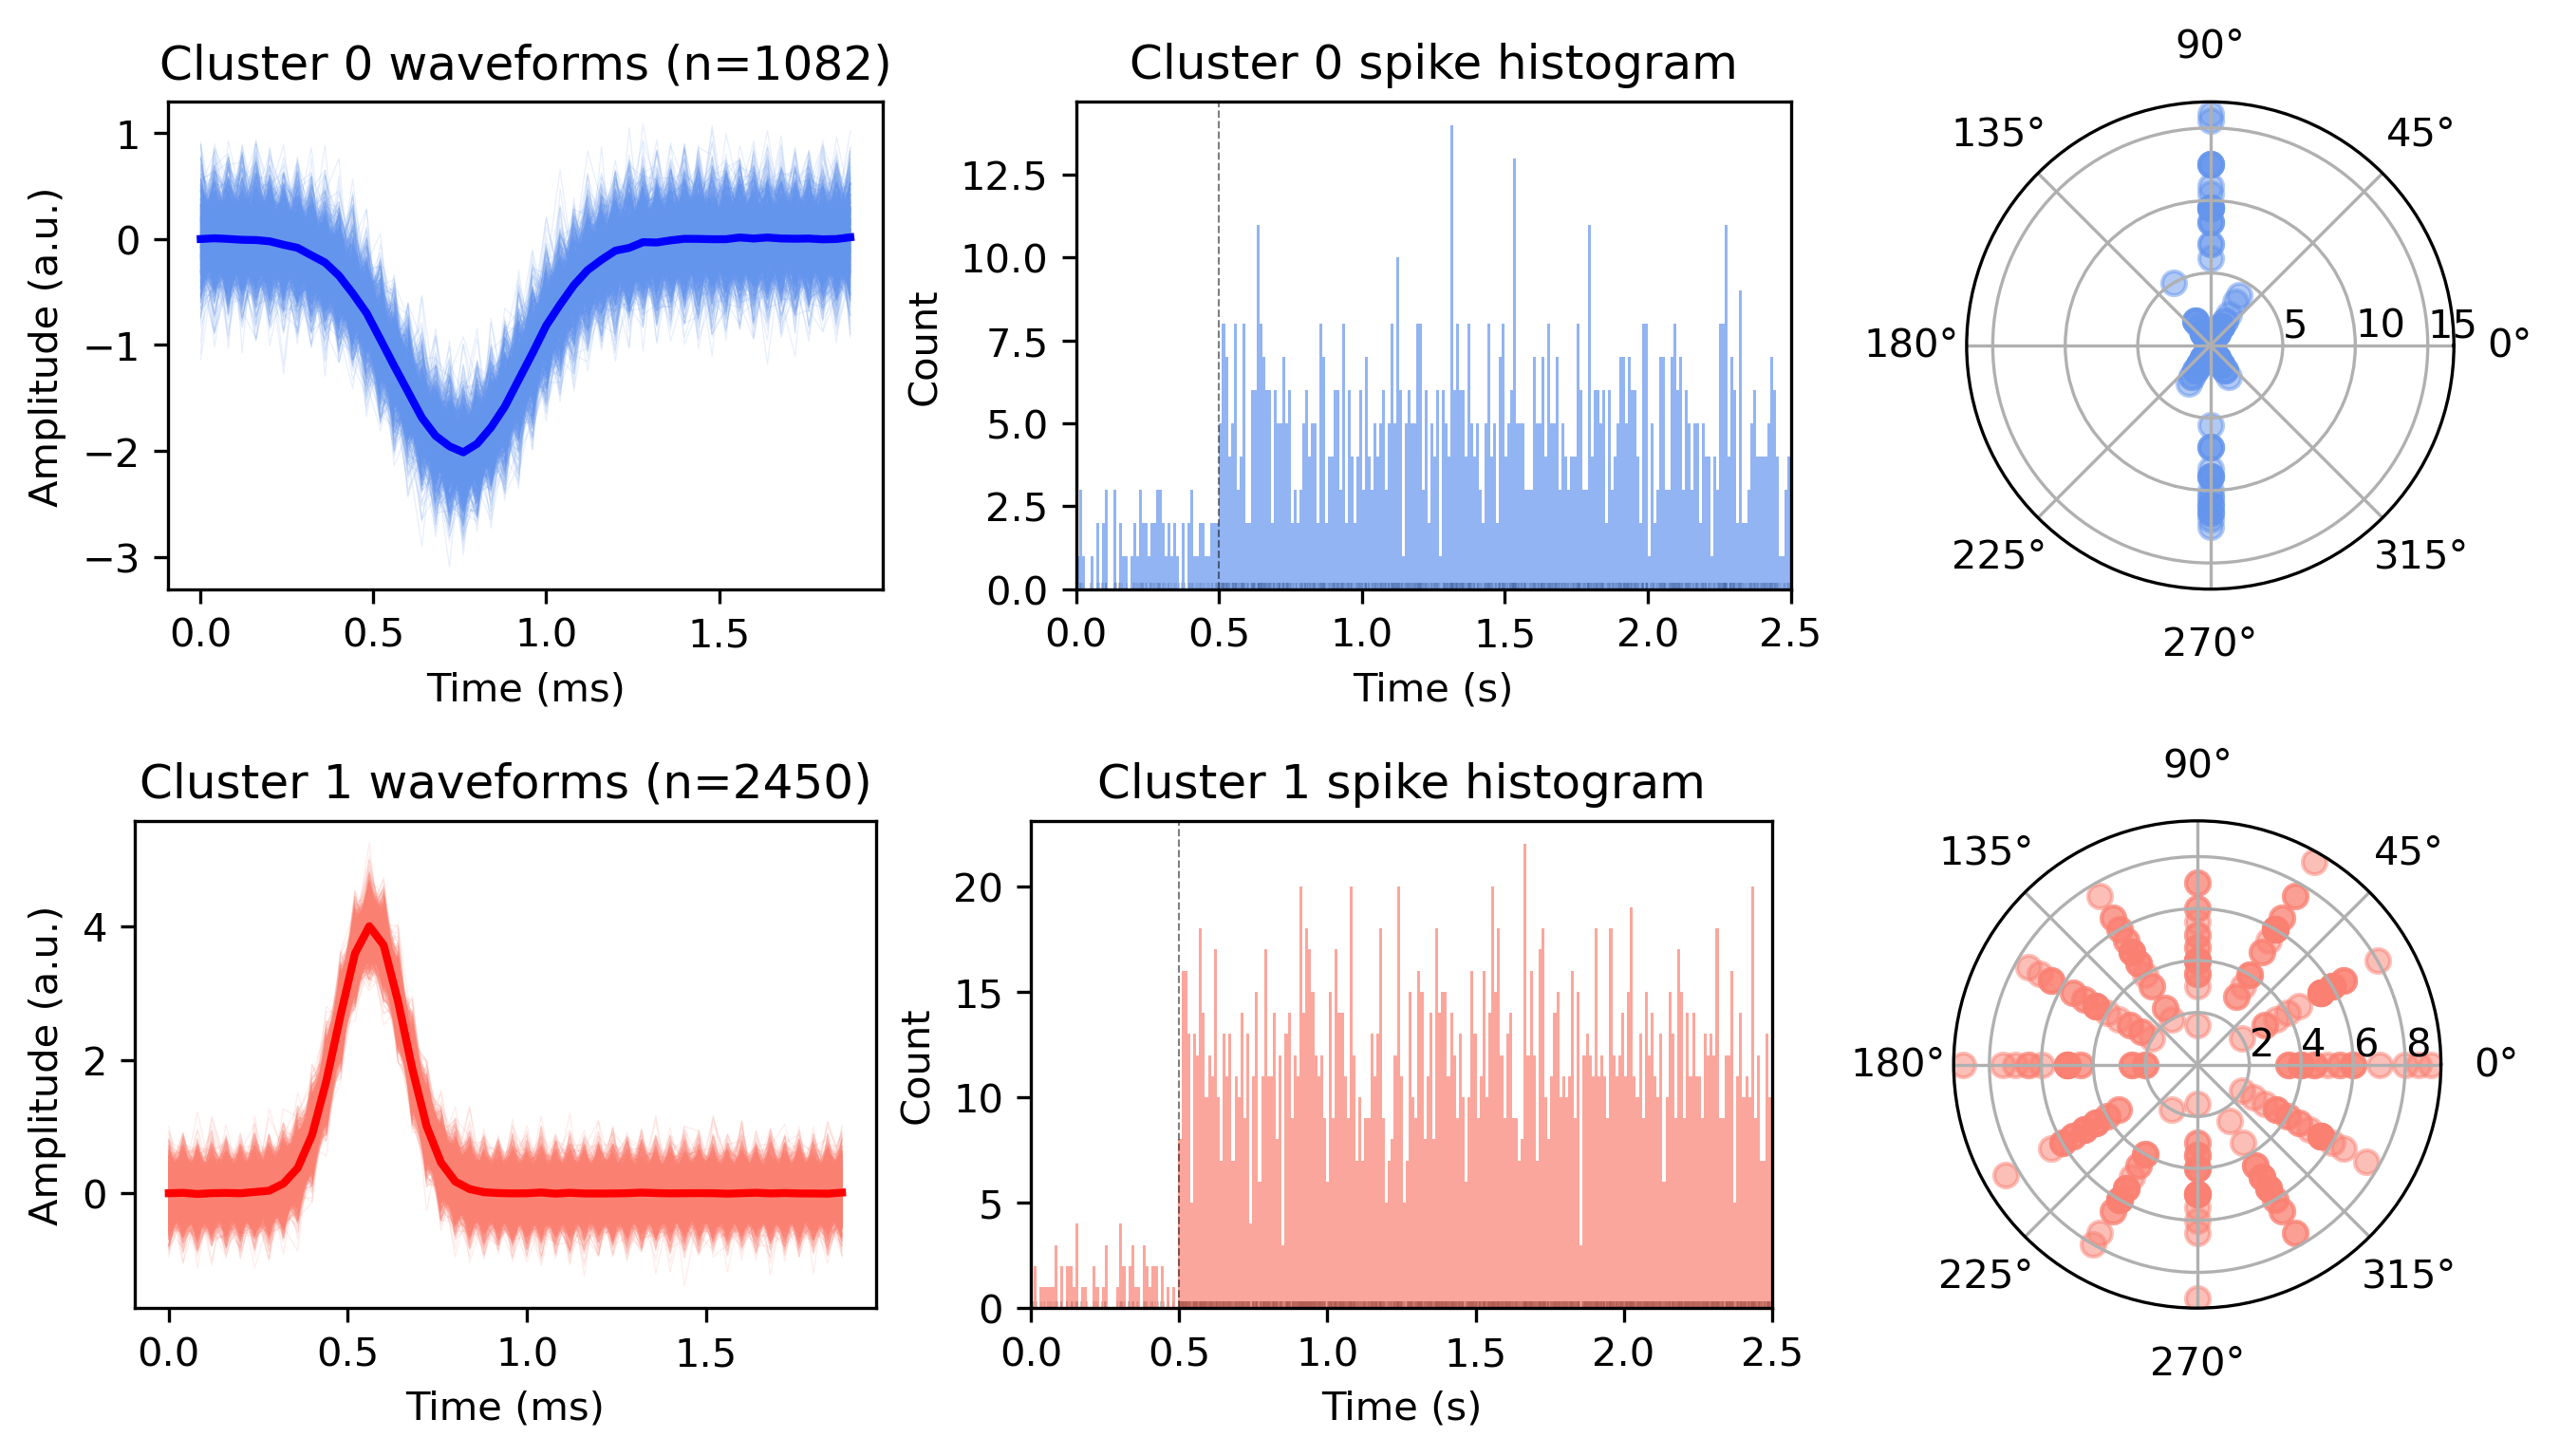

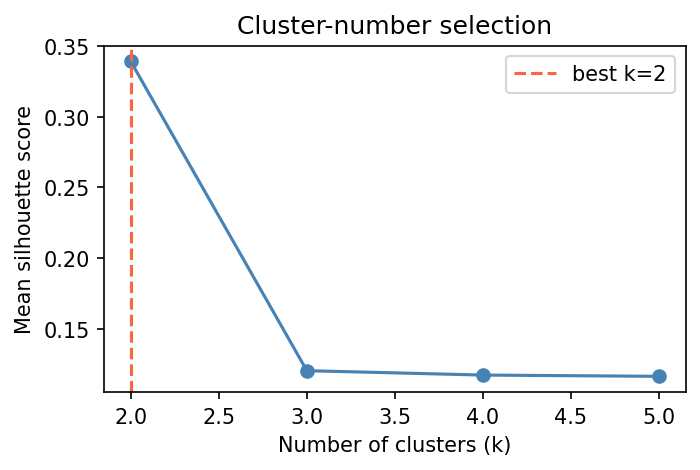


Detected 2 clusters
Preprocessing: zscore_pca (pca_components=0.95)

Quality Metrics:
{'abs_rpvs': 2006,
 'amplitude_drift': {0: -0.04102941155643329, 1: -0.011150303245636971},
 'd_prime': {0: 41.68921302981784, 1: 41.68921302981784},
 'fraction_missing': {0: 0.0026539807031766274, 1: 0.0023172274855212623},
 'isolation_distance': {0: 1776.9438049609794, 1: nan},
 'l_ratio': {0: 0.0, 1: 0.0},
 'neg_silhouette_rel': 0.0,
 'peak_amplitude_snr': {0: 6.680435936772619, 1: 13.269471364695587},
 'rel_rpvs': 0.5679501698754247,
 'silhouette_mean': 0.7720597348984913,
 'snr_per_cluster': {0: 3.3815522763866652, 1: 6.673557250708165},
 'snr_weighted': 5.665077810669699,
 'waveform_stability': {0: 0.999175260352668, 1: 0.9998282535021521}}

K-search results (silhouette scores by k):
{2: 0.3391365344952404,
 3: 0.12053450367852589,
 4: 0.1174385214647439,
 5: 0.11654377253091014}


In [6]:
from neural_cca import run_sorting_pipeline

result = run_sorting_pipeline(
    data,
    preprocess="zscore_pca",   # z-score → PCA → KMeans (recommended)
    pca_components=0.95,        # keep PCs explaining 95% of the variance
    plot=True,
)
print(f"\nDetected {result.n_clusters} clusters")
print(f"Preprocessing: {result.metadata['preprocess']} "
      f"(pca_components={result.metadata['pca_components']})")
print(f"\nQuality Metrics:")
pprint(result.quality)
print(f"\nK-search results (silhouette scores by k):")
pprint(result.k_search)

In [7]:
# See all fields available in the SortingResult object:
result.__dict__.keys()

dict_keys(['cluster_labels', 'n_clusters', 'quality', 'os_metrics', 'k_search', 'metadata'])

## 3. Spike Train Analysis (sta)

In [8]:
from neural_cca import (
    minimal_spike_train_analysis,
    isi_violation_rate,
    firing_rate_stability,
    autocorrelogram,
    fano_factor,
    local_variation,
    cv_log_isi,
    psth,
    trial_to_trial_reliability,
    first_spike_latency,
)

# Comprehensive analysis for each cluster
for cluster_id in np.unique(result.cluster_labels)[:1]:
    cluster_id = int(cluster_id)
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*60}")
    
    # Basic spike train statistics
    stats = minimal_spike_train_analysis(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        n_trials=data.n_trials,
        stim_window=data.stim_window,
    )
    print(f"\nBasic Statistics:")
    pprint(stats)
    
    # ISI violation rate (trial-aware: pass `trials` + `trial_duration`
    # so inter-trial spike pairs are not counted as violations and the
    # rate is normalised by the actual recording duration)
    isi_viol = isi_violation_rate(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        refractory_period=0.001,
        trial_duration=data.stim_window[1],
    )
    print(f"\nISI Violation Rate: {isi_viol:.4f} Hz")

    isi_viol_p = isi_violation_rate(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        refractory_period=0.001,
        trial_duration=data.stim_window[1],
        return_percentage=True,
    )
    print(f"ISI Violation Rate: {isi_viol_p:.4f} %")
    
    # Firing rate stability (requires trials positional arg)
    fr_stability = firing_rate_stability(
        spike_times,
        trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        trial_duration=data.stim_window[1],
    )
    print(f"\nFiring Rate Stability:")
    pprint(fr_stability)
    
    # Autocorrelogram
    acg, acg_time = autocorrelogram(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        max_lag=0.05,
        bin_size=0.0005,
    )
    print(f"\nAutocorrelogram: {len(acg)} bins, max_lag=0.05s")
    
    # Fano factor (no n_trials param; pass trials array)
    ff = fano_factor(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        trial_duration=data.stim_window[1],
        mode="per_trial",
    )
    print(f"Fano Factor: {ff:.4f}")
    
    # Local variation
    lv = local_variation(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
    )
    print(f"Local Variation: {lv:.4f}")
    
    # CV log ISI
    cv_log = cv_log_isi(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
    )
    print(f"CV (log ISI): {cv_log:.4f}")
    
    # PSTH (no angles or stimulus_onset params)
    psth_counts, psth_edges = psth(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        bin_size=0.05,
        trial_duration=data.stim_window[1],
    )
    print(f"\nPSTH: {len(psth_counts)} bins")
    
    # Trial-to-trial reliability (no angles or stimulus_onset params)
    reliability = trial_to_trial_reliability(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        bin_size=0.05,
        trial_duration=data.stim_window[1],
    )
    print(f"\nTrial-to-Trial Reliability: {reliability:.4f}")
    
    # First spike latency (param is stim_onset, not stimulus_onset)
    fsl = first_spike_latency(
        spike_times,
        trials=trials,
        cluster_labels=result.cluster_labels,
        cluster_id=cluster_id,
        stim_onset=data.stim_window[0],
    )
    print(f"\nFirst Spike Latency: mean={fsl['mean']:.4f}s, std={fsl['std']:.4f}s")


CLUSTER 0

Basic Statistics:
{'cv': 1.4649763571118475, 'lvr': 1.0523722120267693, 'mfr': 3.1136690647482013}

ISI Violation Rate: 0.0144 Hz
ISI Violation Rate: 0.5302 %

Firing Rate Stability:
{'cv_of_stat': 0.3396359095722376,
 'mean': 3.113669064748202,
 'std': 1.057513824912694,
 'values': array([1.03597122, 3.61151079, 3.79856115, 3.84172662, 3.28057554])}

Autocorrelogram: 200 bins, max_lag=0.05s
Fano Factor: 9.1733
Local Variation: 1.0161
CV (log ISI): 0.5343

PSTH: 50 bins

Trial-to-Trial Reliability: 0.0856

First Spike Latency: mean=0.4092s, std=0.4458s


## 4. Orientation Selectivity (Basic Metrics)

In [9]:
from neural_cca import (
    dosi_circular_normalised,
    gosi,
    gdsi,
    circular_variance,
    preferred_dori,
    tuning_bandwidth,
)
from neural_cca.sta import calc_mfr_trial

# Compute mean firing rates per trial
mfr_by_trial = calc_mfr_trial(
    spike_times,
    trials=trials,
    all_clusters=False,
    cluster_labels=result.cluster_labels,
    cluster_id=0,
    stim_window=data.stim_window,
    n_trials=data.n_trials,
)
mfrs_0 = np.array([mfr_by_trial[i] for i in range(data.n_trials)])

mfr_by_trial_1 = calc_mfr_trial(
    spike_times,
    trials=trials,
    all_clusters=False,
    cluster_labels=result.cluster_labels,
    cluster_id=1,
    stim_window=data.stim_window,
    n_trials=data.n_trials,
)
mfrs_1 = np.array([mfr_by_trial_1[i] for i in range(data.n_trials)])

for cluster_id, mfrs in [(0, mfrs_0), (1, mfrs_1)]:
    print(f"\n{'='*60}")
    print(f"ORIENTATION SELECTIVITY - CLUSTER {cluster_id}")
    print(f"{'='*60}")
    
    # Orientation and direction selectivity index
    osi = dosi_circular_normalised(mfrs, angles, direction_selectivity=False, p_value=True)
    dsi = dosi_circular_normalised(mfrs, angles, direction_selectivity=True, p_value=True)
    print(f"\nDOSI (Orientation Selectivity):")
    pprint(osi)
    print(f"\nDOSI (Direction Selectivity):")
    pprint(dsi)
    
    # Global orientation selectivity index
    gosi_val = gosi(mfrs, angles, p_value=True)
    gdsi_val = gdsi(mfrs, angles, p_value=True)
    print(f"\ngOSI (Global Orientation Selectivity):")
    pprint(gosi_val)
    print(f"\ngDSI (Global Direction Selectivity):")
    pprint(gdsi_val)
    
    # Circular variance
    cva = circular_variance(mfrs, angles, p_value=True)
    print(f"\nCircular Variance:")
    pprint(cva)
    
    # Preferred orientation and direction
    pref_ori = preferred_dori(mfrs, angles, direction_selectivity=False)
    pref_dir = preferred_dori(mfrs, angles, direction_selectivity=True)
    print(f"\nPreferred Orientation: {pref_ori:.1f}°")
    print(f"Preferred Direction: {pref_dir:.1f}°")
    
    # Tuning bandwidth
    bw = tuning_bandwidth(mfrs, angles)
    print(f"Tuning Bandwidth: {bw:.1f}°")


ORIENTATION SELECTIVITY - CLUSTER 0

DOSI (Orientation Selectivity):
{'p_value': 3.617417255817508e-173, 'value': 0.8956631778651568}

DOSI (Direction Selectivity):
{'p_value': 0.7769825506265444, 'value': 0.022363152912795517}

gOSI (Global Orientation Selectivity):
{'p_value': 3.617417255817508e-173, 'value': 1.0}

gDSI (Global Direction Selectivity):
{'p_value': 0.7769825506265444, 'value': 0.15151515151515152}

Circular Variance:
{'p_value': 3.617417255817508e-173, 'value': 0.10433682213484319}

Preferred Orientation: 89.5°
Preferred Direction: 78.5°
Tuning Bandwidth: 8.3°

ORIENTATION SELECTIVITY - CLUSTER 1

DOSI (Orientation Selectivity):
{'p_value': 0.40441602569404955, 'value': 0.027515857310876867}

DOSI (Direction Selectivity):
{'p_value': 0.6754376296584771, 'value': 0.018116271581865687}

gOSI (Global Orientation Selectivity):
{'p_value': 0.40441602569404955, 'value': 0.375}

gDSI (Global Direction Selectivity):
{'p_value': 0.6754376296584771, 'value': -0.0909090909090909

## 5. Tuning Curve Fitting

In [10]:
from neural_cca import (
    von_mises_fit,
    double_gaussian_fit,
    tuning_curve_interpolation,
    goodness_of_fit,
)

cluster_id = 0
mfrs = mfrs_0

print(f"\nTuning Curve Fitting - Cluster {cluster_id}")
print(f"{'='*60}")

# Orientation von Mises fit — return_fit=True returns (dict, fitted_array)
vm_params, vm_fitted = von_mises_fit(
    mfrs, angles, tuning_type="orientation", return_fit=True,
)
print(f"\nVon Mises Fit (orientation):")
pprint(vm_params)
print(f"  Fitted curve shape: {vm_fitted.shape}")

# Double Gaussian fit
dg_params, dg_fitted = double_gaussian_fit(mfrs, angles, return_fit=True)
print(f"\nDouble Gaussian Fit:")
pprint(dg_params)
print(f"  Fitted curve shape: {dg_fitted.shape}")

# Direction von Mises fit (two bumps at preferred and null)
dvm_params, dvm_fitted = von_mises_fit(
    mfrs, angles, tuning_type="direction", return_fit=True,
)
print(f"\nVon Mises Fit (direction):")
pprint(dvm_params)
print(f"  Fitted curve shape: {dvm_fitted.shape}")

# Tuning curve interpolation — returns a float (preferred angle)
interp_pref = tuning_curve_interpolation(
    mfrs, angles, model="von_mises_orientation",
)
print(f"\nTuning Curve Interpolation:")
print(f"  Preferred orientation (interpolated): {interp_pref:.1f}°")

# Goodness of fit comparison
gof_vm = goodness_of_fit(mfrs, vm_fitted)
gof_dg = goodness_of_fit(mfrs, dg_fitted)
gof_dvm = goodness_of_fit(mfrs, dvm_fitted)

print(f"\nGoodness of Fit (R²):")
print(f"  Von Mises (orientation): {gof_vm:.4f}")
print(f"  Double Gaussian:         {gof_dg:.4f}")
print(f"  Von Mises (direction):   {gof_dvm:.4f}")



Tuning Curve Fitting - Cluster 0

Von Mises Fit (orientation):
{'amplitude': -24870.402350181514,
 'bandwidth_hwhh': inf,
 'baseline': 24872.506659662344,
 'kappa': -0.00015155021592334894,
 'preferred_angle': 89.53367113086874,
 'r_squared': 0.5108083617018301,
 'tuning_type': 'orientation'}
  Fitted curve shape: (240,)

Double Gaussian Fit:
{'amp1': 10.274915358785366,
 'amp2': 9.719797740535391,
 'baseline': -0.0013153370391946137,
 'r_squared': 0.9200638186901445,
 'sigma': 0.2599810144034919,
 'theta0': 89.39451996839533}
  Fitted curve shape: (240,)

Von Mises Fit (direction):
{'amplitude_null': 2.7561090436938877e-06,
 'amplitude_pref': 2.6072372269940566e-06,
 'bandwidth_hwhh': 17.409246393580815,
 'baseline': -0.002765124637255705,
 'ds_ratio': -0.027757263690665206,
 'kappa': -15.131593636598032,
 'preferred_angle': 89.38072125009067,
 'r_squared': 0.92006359319998,
 'tuning_type': 'direction'}
  Fitted curve shape: (240,)

Tuning Curve Interpolation:
  Preferred orientation

## 6. Harmonic Analysis (F0/F1/F2)

In [11]:
from neural_cca import (
    compute_f0_f1_f2,
    modulation_ratio_per_orientation,
    cross_orientation_suppression,
)

cluster_id = 0

# compute_f0_f1_f2 expects a PSTH array, not raw spike times.
# Build a per-trial PSTH first, then extract harmonics.
bin_size = 0.05
psth_fs = 1.0 / bin_size
stim_freq = 2.0
bins = np.arange(data.stim_window[0], data.stim_window[1] + bin_size, bin_size)

# Filter spikes for cluster 0
cl_mask = result.cluster_labels == cluster_id
cl_spike_times = spike_times[cl_mask]
cl_trials = trials[cl_mask]

# Build per-trial PSTHs
psth_list = []
for t_idx in range(data.n_trials):
    t_spikes = cl_spike_times[(cl_trials == t_idx) & (cl_spike_times > data.stim_window[0])]
    if len(t_spikes) == 0:
        psth_list.append(np.zeros(len(bins) - 1))
    else:
        counts, _ = np.histogram(t_spikes, bins=bins)
        psth_list.append(counts / bin_size)

psth_array = np.array(psth_list)
F0, F1, F2 = compute_f0_f1_f2(psth_array, psth_fs, stim_freq)

print(f"\nHarmonic Analysis - Cluster {cluster_id}")
print(f"{'='*60}")
print(f"\nF0/F1/F2 Components (stimulus frequency = {stim_freq} Hz):")
print(f"  F0 (mean): {F0.mean():.4f}")
print(f"  F1 (mean): {F1.mean():.4f}")
print(f"  F2 (mean): {F2.mean():.4f}")

# F1/F0 classification
mean_f0 = F0.mean()
mean_f1 = F1.mean()
if mean_f0 > 0:
    f1_f0_ratio = mean_f1 / mean_f0
    cell_type = "Simple Cell" if f1_f0_ratio > 1 else "Complex Cell"
    print(f"\nF1/F0 Ratio: {f1_f0_ratio:.3f} → {cell_type}")

# Modulation ratio per orientation (spike-level API with correct param names)
mod_ratio = modulation_ratio_per_orientation(
    spike_times,
    trials,
    angles,
    bin_size=bin_size,
    stim_window=data.stim_window,
    stim_frequency=stim_freq,
    cluster_labels=result.cluster_labels,
    cluster_id=cluster_id,
)
print(f"\nModulation Ratio per Orientation:")
for ori, ratio in sorted(mod_ratio.items()):
    print(f"  {ori:6.1f}°: {ratio:.4f}")

# Cross-orientation suppression takes (responses, angles), not spike-level data
cos = cross_orientation_suppression(mfrs_0, angles)
print(f"\nCross-Orientation Suppression: {cos:.4f}")


Harmonic Analysis - Cluster 0

F0/F1/F2 Components (stimulus frequency = 2.0 Hz):
  F0 (mean): 2.1042
  F1 (mean): 1.0810
  F2 (mean): 1.2223

F1/F0 Ratio: 0.514 → Complex Cell

Modulation Ratio per Orientation:
     0.0°: 0.0000
    30.0°: 0.0000
    60.0°: 1.0132
    90.0°: 0.3573
   120.0°: 1.0809
   150.0°: 0.0000
   180.0°: 0.0000
   210.0°: 0.0000
   240.0°: 0.8736
   270.0°: 0.4095
   300.0°: 1.0424
   330.0°: 0.0000

Cross-Orientation Suppression: 1.0000


## 7. Temporal Frequency Analysis

In [12]:
from neural_cca import f1_phase

print(f"\nTemporal Frequency Analysis")
print(f"{'='*60}")

# F1 phase analysis on PSTH (psth() takes no angles or stimulus_onset params)
psth_counts, psth_times = psth(
    spike_times,
    trials=trials,
    cluster_labels=result.cluster_labels,
    cluster_id=0,
    bin_size=0.05,
    trial_duration=data.stim_window[1],
)

# Compute F1 phase for cluster 0
# f1_phase expects (psth, fs, f_stim), where fs = 1/bin_size
f1_phase_result = f1_phase(
    psth_counts,
    fs=1.0 / 0.05,
    f_stim=2.0,
)
print(f"\nF1 Phase (Cluster 0): {f1_phase_result:.4f} rad ({np.rad2deg(f1_phase_result):.1f}°)")

print(f"\nNote: Temporal Frequency Tuning requires multi-TF data")
print(f"This notebook demonstrates with single TF (2 Hz).")
print(f"For full temporal_frequency_tuning analysis, data with multiple")
print(f"temporal frequencies would be needed.")


Temporal Frequency Analysis

F1 Phase (Cluster 0): 1.8850 rad (108.0°)

Note: Temporal Frequency Tuning requires multi-TF data
This notebook demonstrates with single TF (2 Hz).
For full temporal_frequency_tuning analysis, data with multiple
temporal frequencies would be needed.


## 8. Population Analysis

In [13]:
from neural_cca import (
    orientation_map_statistics,
    signal_correlations,
    noise_correlations,
)

print(f"\nPopulation Analysis")
print(f"{'='*60}")

# Preferred orientations for population
preferred_oris = np.array([
    preferred_dori(mfrs_0, angles, direction_selectivity=False),
    preferred_dori(mfrs_1, angles, direction_selectivity=False),
])

# Orientation map statistics (no radius_um param)
pop_stats = orientation_map_statistics(preferred_oris)
print(f"\nOrientation Map Statistics (2 neurons):")
pprint(pop_stats)

# Signal correlations
tuning_curves = np.array([mfrs_0, mfrs_1])
sig_corr = signal_correlations(tuning_curves)
print(f"\nSignal Correlations (Tuning Curve Similarity):")
print(f"  Shape: {sig_corr.shape}")
print(f"  Corr[0,1]: {sig_corr[0,1]:.4f}")
pprint(sig_corr)

# Noise correlations — requires trial_angles as second argument
trial_rates = np.array([mfrs_0, mfrs_1])
noise_corr = noise_correlations(trial_rates, angles)
print(f"\nNoise Correlations (Trial-by-Trial Rate Similarity):")
print(f"  Shape: {noise_corr.shape}")
print(f"  Corr[0,1]: {noise_corr[0,1]:.4f}")
pprint(noise_corr)


Population Analysis

Orientation Map Statistics (2 neurons):
{'concentration': 0.6276843144239239,
 'is_uniform': True,
 'mean_ori': 63.97348377444,
 'rayleigh_p': 0.5206347758181359,
 'rayleigh_z': 0.7879751971476627}

Signal Correlations (Tuning Curve Similarity):
  Shape: (2, 2)
  Corr[0,1]: -0.1333
array([[ 1.        , -0.13328747],
       [-0.13328747,  1.        ]])

Noise Correlations (Trial-by-Trial Rate Similarity):
  Shape: (2, 2)
  Corr[0,1]: -0.0754
array([[ 1.        , -0.07544554],
       [-0.07544554,  1.        ]])


## 9. Statistical Testing

In [14]:
from neural_cca import (
    orientation_selectivity_significance,
    anova_across_orientations,
    bootstrap_ci,
)

print(f"\nStatistical Testing - Cluster 0")
print(f"{'='*60}")

# Orientation selectivity significance — takes (responses, angles), not spike data
os_sig = orientation_selectivity_significance(
    mfrs_0,
    angles,
)
print(f"\nOrientation Selectivity Significance (Permutation + Rayleigh):")
pprint(os_sig)

# ANOVA across orientations — takes spike-level data
anova_result = anova_across_orientations(
    spike_times,
    trials,
    angles,
    stim_window=data.stim_window,
    cluster_labels=result.cluster_labels,
    cluster_id=0,
)
print(f"\nANOVA Across Orientations:")
pprint({k: v for k, v in anova_result.items() if k not in ('group_means', 'group_stds')})

# Bootstrap CI on OSI — needs (data, stat_func, ...)
from neural_cca import dosi_circular_normalised

def osi_func(arr):
    return dosi_circular_normalised(arr, angles)

osi_ci = bootstrap_ci(
    mfrs_0,
    stat_func=osi_func,
    n_bootstrap=200,
    ci_level=0.95,
)
print(f"\nBootstrap CI on OSI (200 resamples, 95% level):")
pprint(osi_ci)


Statistical Testing - Cluster 0

Orientation Selectivity Significance (Permutation + Rayleigh):
{'is_significant': True,
 'osi': 0.8956631778651568,
 'p_permutation': 0.0,
 'p_rayleigh': 3.617417255817508e-173}

ANOVA Across Orientations:
{'f_stat': 238.93906975157014, 'p_value': 1.8407833627288997e-118}

Bootstrap CI on OSI (200 resamples, 95% level):
{'ci_lower': 0.011911781303329929,
 'ci_upper': 0.20971634876749334,
 'estimate': 0.8956631778651568,
 'se': 0.05365751229195706}


## 10. Composite Metrics: get_os_metrics

In [15]:
from neural_cca import get_os_metrics

print(f"\nComposite Orientation Selectivity Metrics - Cluster 0")
print(f"{'='*60}")

os_metrics = get_os_metrics(
    spike_times,
    trials=trials,
    angles=angles,
    bin_size=0.05,
    all_clusters=False,
    cluster_labels=result.cluster_labels,
    cluster_id=0,
    stim_window=data.stim_window,
    stim_frequency=2.0,
    return_verbose=1,
    fit_model="double_gaussian",  # or "von_mises_orientation"
    compute_gosi=True,
    compute_p_values=True,
    bootstrap_ci=True,
    n_bootstrap=200,
    ci_level=0.95,
)

print(f"\nComplete OS Metrics Dictionary (all available fields):")
pprint(os_metrics)


Composite Orientation Selectivity Metrics - Cluster 0

Complete OS Metrics Dictionary (all available fields):
{'anova_p_value': 1.8407833627288997e-118,
 'circular_variance': 0.10433682213484319,
 'closest_orientation': 270.0,
 'dsi': 0.022363152912795517,
 'dsi_ci': {'ci_lower': 0.003673450338930125,
            'ci_upper': 0.0867672784892341,
            'estimate': 0.022363152912795517,
            'se': 0.02127103196265653},
 'dsi_p_value': 0.7769825506265444,
 'f0_mean': 2.1041666666666665,
 'f1_f0_mean': 0.5113375985599604,
 'f1_mean': 1.07593953030325,
 'f2_f0_mean': 0.583268445830898,
 'f2_f1_mean': 1.1406719307821502,
 'f2_mean': 1.2272940214358479,
 'fit_bandwidth': 0.2599810144034919,
 'fit_model': 'double_gaussian',
 'fit_preferred_angle': 89.39451996839533,
 'fit_r_squared': 0.9200638186901445,
 'gdsi': 0.15151515151515152,
 'gdsi_ci': {'ci_lower': -0.48392857142857115,
             'ci_upper': 0.6516666666666671,
             'estimate': 0.15151515151515152,
            

## 11. Visualization Gallery

In [16]:
from neural_cca import (
    orientation_scatter_vm,
    plot_tuning_curve,
    plot_direction_polar,
    plot_f1f0_bars,
    plot_f1_phase,
    plot_population_orientation_histogram,
    plot_signal_correlation_matrix,
    plot_modulation_ratio,
)

print(f"\nVisualization Gallery")
print(f"{'='*60}")


Visualization Gallery


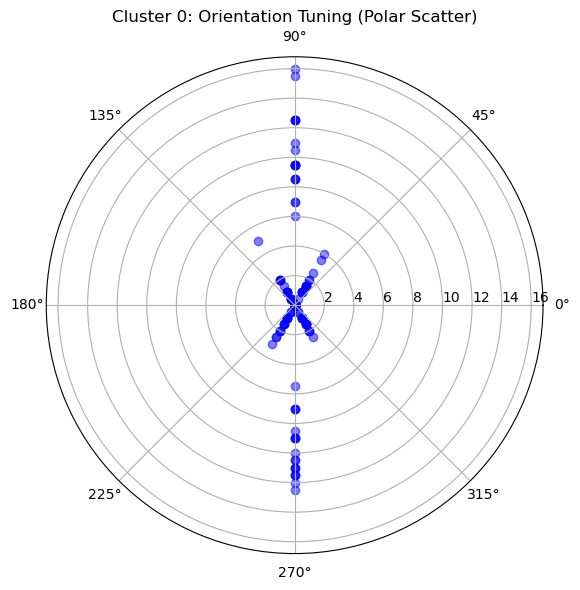

In [17]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": "polar"})
orientation_scatter_vm(
    mfrs_0,
    angles,
    ax=ax,
)
ax.set_title("Cluster 0: Orientation Tuning (Polar Scatter)")
plt.tight_layout()
plt.show()
plt.close('all')

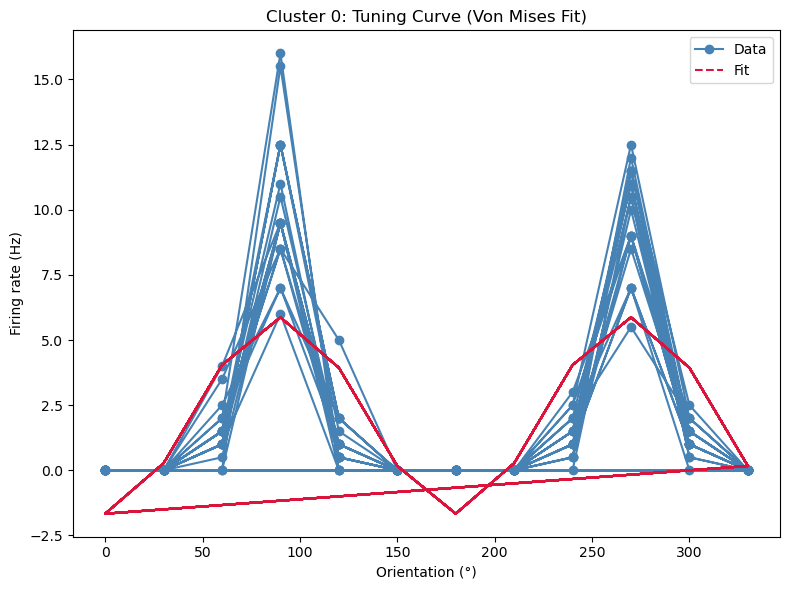

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
# plot_tuning_curve() uses 'fitted' param (not 'fitted_curve'/'fitted_angles')
plot_tuning_curve(
    mfrs_0,
    angles,
    fitted=vm_fitted,
    ax=ax,
)
ax.set_title("Cluster 0: Tuning Curve (Von Mises Fit)")
plt.tight_layout()
plt.show()
plt.close('all')

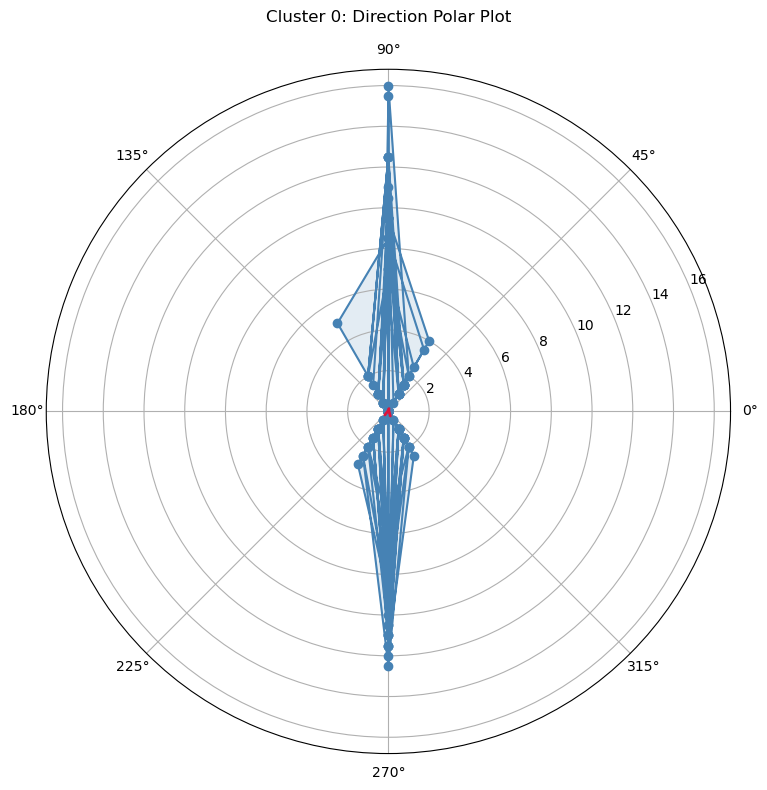

In [19]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
plot_direction_polar(
    mfrs_0,
    angles,
    ax=ax,
)
ax.set_title("Cluster 0: Direction Polar Plot", pad=15)
plt.tight_layout()
plt.show()
plt.close('all')

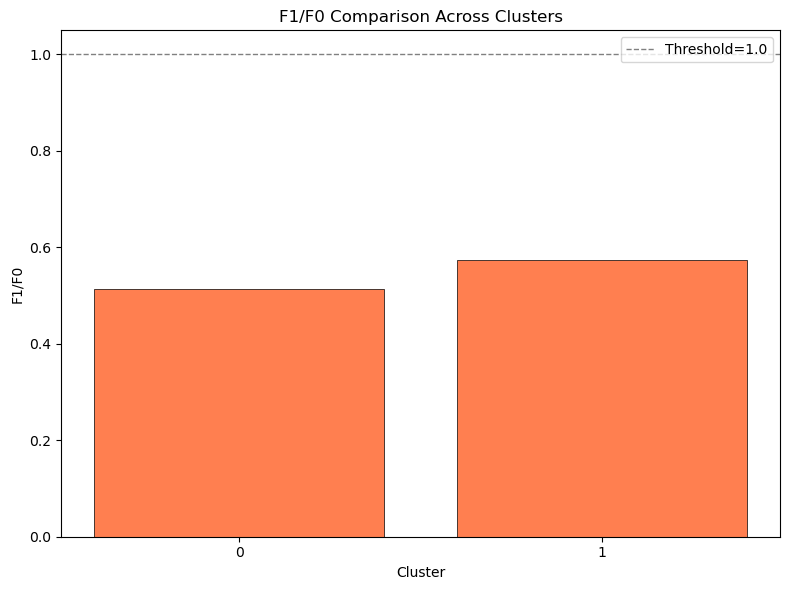

In [20]:
# Build per-trial PSTHs for each cluster, then compute F0/F1/F2
bin_size_viz = 0.05
psth_fs_viz = 1.0 / bin_size_viz
bins_viz = np.arange(data.stim_window[0], data.stim_window[1] + bin_size_viz, bin_size_viz)

f0f1f2_data = {}
for cl_id in [0, 1]:
    cl_mask_viz = result.cluster_labels == cl_id
    cl_st = spike_times[cl_mask_viz]
    cl_tr = trials[cl_mask_viz]
    
    psth_list_viz = []
    for t_idx in range(data.n_trials):
        t_spikes = cl_st[(cl_tr == t_idx) & (cl_st > data.stim_window[0])]
        if len(t_spikes) == 0:
            psth_list_viz.append(np.zeros(len(bins_viz) - 1))
        else:
            counts, _ = np.histogram(t_spikes, bins=bins_viz)
            psth_list_viz.append(counts / bin_size_viz)
    
    psth_arr = np.array(psth_list_viz)
    f0, f1, f2 = compute_f0_f1_f2(psth_arr, psth_fs_viz, 2.0)
    f0f1f2_data[cl_id] = float(f1.mean() / f0.mean()) if f0.mean() > 0 else 0.0

fig, ax = plt.subplots(figsize=(8, 6))
# plot_f1f0_bars expects an array of F1/F0 ratios (one per cluster)
plot_f1f0_bars(
    list(f0f1f2_data.values()),
    cluster_ids=list(f0f1f2_data.keys()),
    ax=ax,
)
ax.set_title("F1/F0 Comparison Across Clusters")
plt.tight_layout()
plt.show()
plt.close('all')

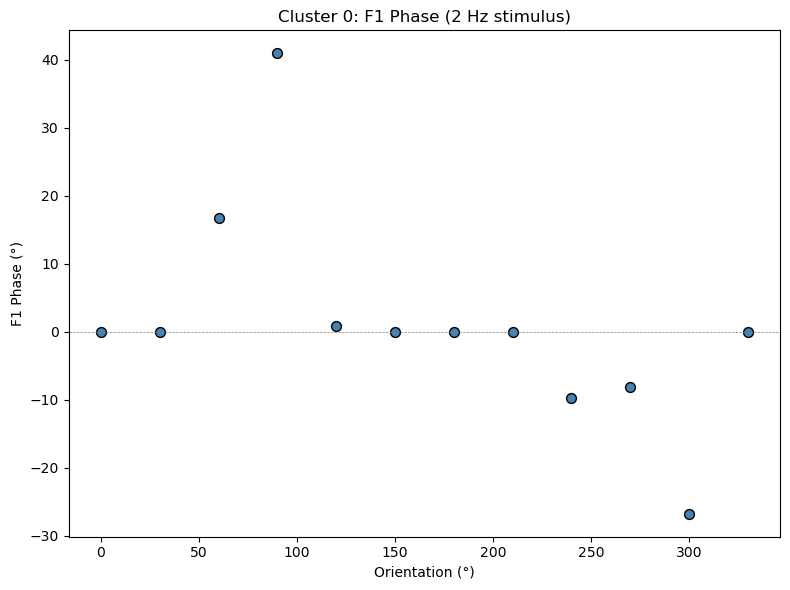

In [21]:
# Compute F1 phase per orientation for cluster 0
unique_angles = np.unique(angles)
per_ori_phases = []
for ang in unique_angles:
    ang_trials = np.where(angles == ang)[0]
    trial_phases = []
    for t_idx in ang_trials:
        cl_mask_ph = result.cluster_labels == 0
        t_spikes = spike_times[cl_mask_ph & (trials == t_idx) & (spike_times > data.stim_window[0])]
        if len(t_spikes) == 0:
            continue
        counts_ph, _ = np.histogram(t_spikes, bins=bins_viz)
        rate_ph = counts_ph / bin_size_viz
        ph = f1_phase(rate_ph, fs=1.0/bin_size_viz, f_stim=2.0)
        trial_phases.append(ph)
    per_ori_phases.append(np.mean(trial_phases) if trial_phases else 0.0)

fig, ax = plt.subplots(figsize=(8, 6))
plot_f1_phase(
    per_ori_phases,
    unique_angles,
    ax=ax,
)
ax.set_title("Cluster 0: F1 Phase (2 Hz stimulus)")
plt.tight_layout()
plt.show()
plt.close('all')

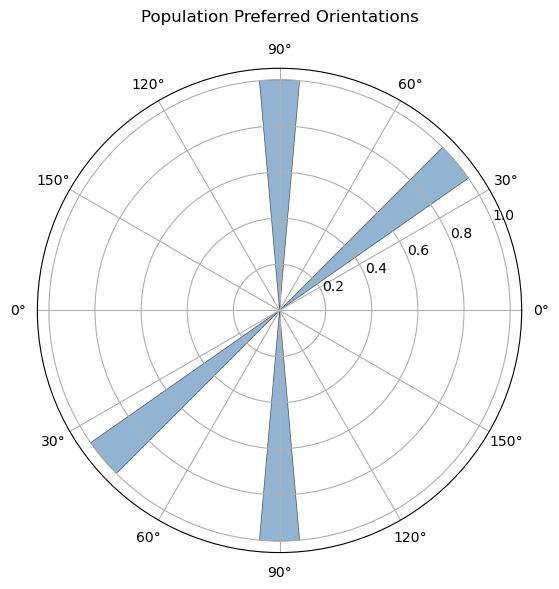

In [22]:
preferred_oris_all = np.array([
    preferred_dori(mfrs_0, angles, direction_selectivity=False),
    preferred_dori(mfrs_1, angles, direction_selectivity=False),
])

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": "polar"})
# plot_population_orientation_histogram has no 'title' param
plot_population_orientation_histogram(
    preferred_oris_all,
    ax=ax,
)
ax.set_title("Population Preferred Orientations", pad=15)
plt.tight_layout()
plt.show()
plt.close('all')

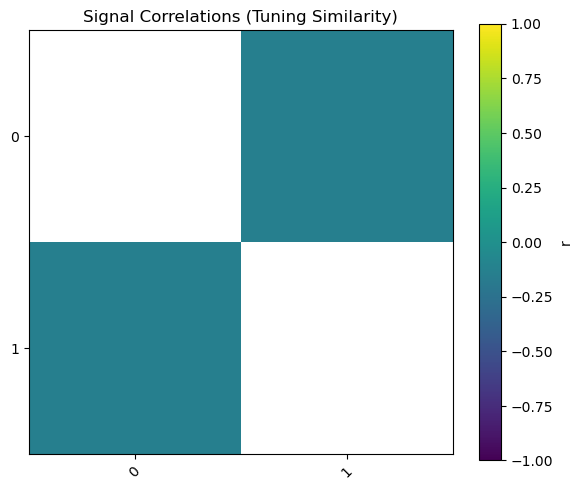

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
# plot_signal_correlation_matrix uses 'ids' param (not 'cluster_ids' or 'title')
plot_signal_correlation_matrix(
    sig_corr,
    ids=[0, 1],
    ax=ax,
)
ax.set_title("Signal Correlations (Tuning Similarity)")
plt.tight_layout()
plt.show()
plt.close('all')

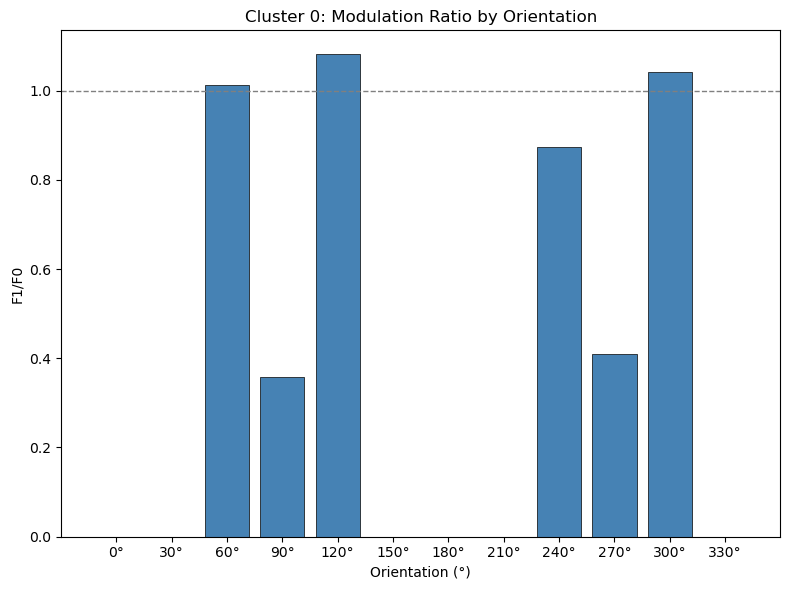

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
# plot_modulation_ratio takes (mod_dict, ax=) — no angles or title param
plot_modulation_ratio(
    mod_ratio,
    ax=ax,
)
ax.set_title("Cluster 0: Modulation Ratio by Orientation")
plt.tight_layout()
plt.show()
plt.close('all')

## 12. Export Results to Zarr

In [25]:
import tempfile, os
from neural_cca import to_zarr_flat, to_zarr_clustered, read_zarr_sorting

# Use a temporary directory so we don't leave artefacts
tmpdir = tempfile.mkdtemp()
flat_store = os.path.join(tmpdir, "sorting_flat.zarr")
clustered_store = os.path.join(tmpdir, "sorting_clustered.zarr")

# --- Flat export: arrays keep their original (n_spikes, ...) shape ----------
root_flat = to_zarr_flat(result, data, flat_store)

print("Flat export")
print(f"  Store: {flat_store}")
print(f"  cluster_labels: {root_flat['cluster_labels'].shape}")
print(f"  spike_times   : {root_flat['spike_times'].shape}")
print(f"  waveforms     : {root_flat['waveforms'].shape}")
print(f"  trials        : {root_flat['trials'].shape}")
print(f"  angles        : {root_flat['angles'].shape}")

# --- Clustered export: reshaped to (n_clusters, max_spikes, ...) ------------
root_cl = to_zarr_clustered(result, data, clustered_store)

print(f"\nClustered export")
print(f"  Store: {clustered_store}")
print(f"  cluster_ids   : {root_cl['cluster_ids'].shape}")
print(f"  spike_count   : {root_cl['spike_count'].shape}")
print(f"  spike_times   : {root_cl['spike_times'].shape}")
print(f"  waveforms     : {root_cl['waveforms'].shape}")
print(f"  trials        : {root_cl['trials'].shape}")
print(f"  angles        : {root_cl['angles'].shape}")

Flat export
  Store: /var/folders/44/d1_rx5gs6hx121g9yghqhvm80000gn/T/tmpdc6v7eln/sorting_flat.zarr
  cluster_labels: (3532,)
  spike_times   : (3532,)
  waveforms     : (3532, 48)
  trials        : (3532,)
  angles        : (240,)

Clustered export
  Store: /var/folders/44/d1_rx5gs6hx121g9yghqhvm80000gn/T/tmpdc6v7eln/sorting_clustered.zarr
  cluster_ids   : (2,)
  spike_count   : (2,)
  spike_times   : (2, 2450)
  waveforms     : (2, 2450, 48)
  trials        : (2, 2450)
  angles        : (240,)


In [26]:
# --- Roundtrip verification: read back and compare --------------------------
result_rt, data_rt = read_zarr_sorting(flat_store)

print("Roundtrip verification (flat store)")
print(f"  Labels match:       {np.array_equal(result.cluster_labels, result_rt.cluster_labels)}")
print(f"  Spike times match:  {np.allclose(data.spike_times, data_rt.spike_times)}")
print(f"  Waveforms match:    {np.allclose(data.waveforms, data_rt.waveforms)}")
print(f"  Trials match:       {np.array_equal(data.trials, data_rt.trials)}")
print(f"  Angles match:       {np.allclose(data.angles, data_rt.angles)}")
print(f"  n_clusters:         {result_rt.n_clusters}")
print(f"  Quality keys:       {sorted(result_rt.quality.keys())}")

# Clean up temporary files
import shutil
shutil.rmtree(tmpdir)
print(f"\nCleaned up temporary directory.")

Roundtrip verification (flat store)
  Labels match:       True
  Spike times match:  True
  Waveforms match:    True
  Trials match:       True
  Angles match:       True
  n_clusters:         2
  Quality keys:       ['abs_rpvs', 'amplitude_drift', 'd_prime', 'fraction_missing', 'isolation_distance', 'l_ratio', 'neg_silhouette_rel', 'peak_amplitude_snr', 'rel_rpvs', 'silhouette_mean', 'snr_per_cluster', 'snr_weighted', 'waveform_stability']

Cleaned up temporary directory.
